In [60]:
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
#from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html
import matplotlib.patches as patches

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

from matplotlib.colors import LinearSegmentedColormap

# Defina um mapa de cores personalizado para criar o degradê
cmap = LinearSegmentedColormap.from_list('custom', ['orange', 'orange', 'darkorange', 'darkorange'], N=256)

from altaipony.ffd import FFD, generate_random_power_law_distribution
import matplotlib.pyplot as plt

for att in ['axes.labelsize', 'axes.titlesize', 'legend.fontsize',
            'legend.fontsize', 'xtick.labelsize', 'ytick.labelsize']:
    plt.rcParams[att] = 10


In [61]:
#### Parametros do setor 1 ######
data=np.loadtxt('parametros_setor1.txt')
data4=np.loadtxt('par_s1.txt')
dur=data[:,0]
sub=data[:,1]
des=data[:,2]
ampl=data[:,3]
ener = data4
#ener = data[:,4]
#### Parametros do setor 27 2Min ######
data2=np.loadtxt('par_setor27_2Min.txt')
data5=np.loadtxt('par_s27_2min.txt')
dur2=data2[:,0]
sub2=data2[:,1]
des2=data2[:,2]
ampl2=data2[:,3]
ener2 = data5
#ener2 = data2[:,4]
#### Parametros do setor 27 20s ######
data3=np.loadtxt('par_setor27_20s.txt')
data6=np.loadtxt('par_s27_20s.txt')
dur3=data3[:,0]
sub3=data3[:,1]
des3=data3[:,2]
ampl3=data3[:,3]
ener3 = data6
#ener3= data3[:,4]

print(np.log10(ener))

[33.77838281 32.62380215 33.14652182 32.37795248 33.65943793 32.88899282
 32.18087964 32.83423054 32.65797703 32.12745469 33.71343762 32.98267232
 34.10444955 33.51042972 32.87115069 32.98544713 33.30100177 33.11125243
 32.17669595 32.57904238 32.49435917 32.51497785 32.70172596 32.83588453
 33.51626691 32.50927916 33.15294235 31.95701362 33.05351636 32.80439434
 33.96701601 33.47928155 32.37902617]


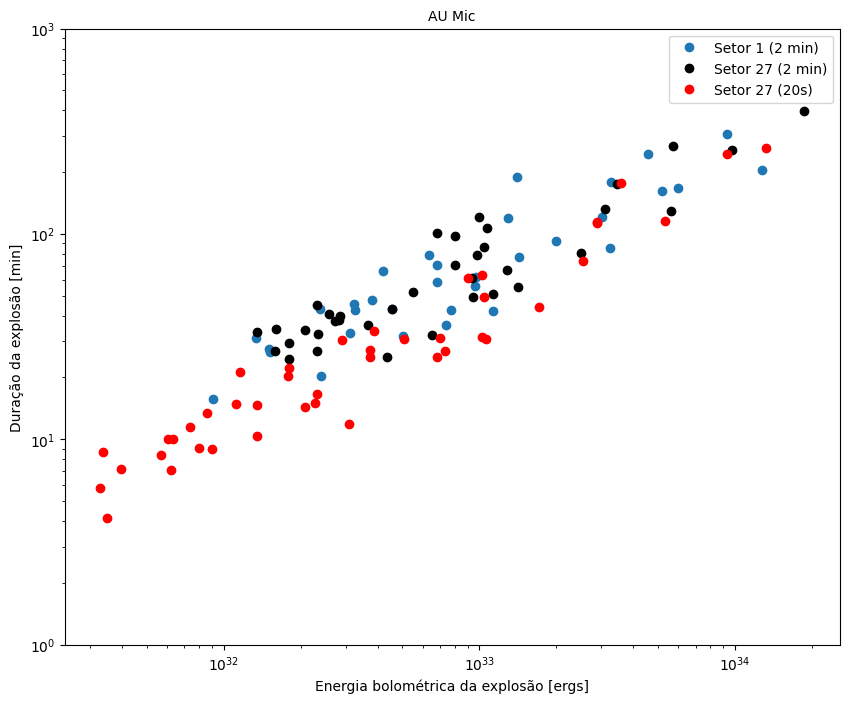

In [62]:
## Definindo eixo x para as energias
x_s1 = ener
x_s27 = ener2
x_s27_20s = ener3
# Definindo o eixo y para a duração 
y_s1 = dur
y_s27 = dur2
y_s27_20s = dur3
plt.figure(figsize=(10, 8))

plt.yscale('log')
plt.xscale('log')
plt.plot(x_s1, y_s1, 'o', label = 'Setor 1 (2 min)')
plt.plot(x_s27, y_s27, 'ko', label = 'Setor 27 (2 min)')
plt.plot(x_s27_20s, y_s27_20s, 'ro', label = 'Setor 27 (20s)')
plt.ylim(1e0,1e3)
#plt.xlim(1e28,1e37)
plt.title('AU Mic')
plt.xlabel("Energia bolométrica da explosão [ergs]")
plt.ylabel("Duração da explosão [min]")
plt.legend()
plt.show()

In [63]:

x = []
ene = []
tamanho = [np.log10]
count=0
for j in range(11):
    count=0
    ene.append(32.4+j*0.15)
    for i in range(len(ener)):
        if (32.55+(j*0.15))>np.log10(ener[i]) and np.log10(ener[i])>(32.4+(j*0.15)):
            count+=1
    x.append(count)

x2 = []
ene2 = []
count2=0
for j in range(11):
    count2 = 0
    ene2.append(32.1+j*0.2)
    for i in range(len(ener2)):
        if (32.5+(j*0.2))>np.log10(ener2[i]) and np.log10(ener2[i])>(32.1+(j*0.2)):
            count2+=1
    x2.append(count2)

x3 = []
ene3 = []
count3=0
for j in range(11):
    count3 = 0
    ene3.append(31.5+j*0.25)
    for i in range(len(ener3)):
        if (31.75+(j*0.25))>np.log10(ener3[i]) and np.log10(ener3[i])>(31.5+(j*0.25)):
            count3+=1
    x3.append(count3)


In [64]:
#Flare frequence minumun to make pre-biotic life 
T_star = 3700
R_star = 0.75
T_sun = 5780

In [65]:
import random as rd

vg = []

for x in np.linspace(30.5,32.3,20):
    vg.append(25.5*((10e34)/10**(x))*((R_star)**2)*((T_star/T_sun)**4))

ValueError: x and y must be the same size

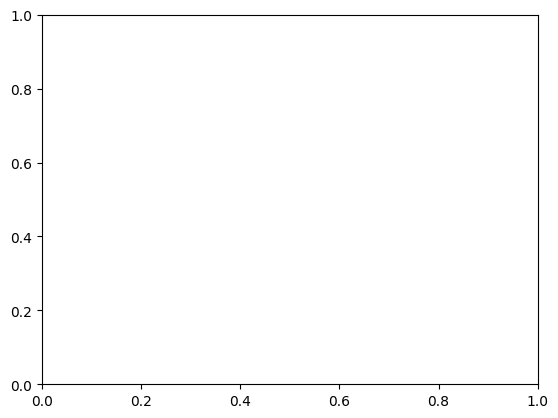

In [66]:
E_u = np.linspace(30.5,32.3,20)
coefficients1 = np.polyfit(E_u, np.log10(vg), 1)
slope1=coefficients1[0]
intercept1 = ((np.log10(vg[0]) - (slope1*E_u[0])))
xene3 = [i for i in range(30,40)]
yv4 = [(xene3[i])*slope1  + intercept1   for i in range(len(xene3))]
plt.scatter((ene),np.log10(x_y), label = 'Sector 1(2 Min)' , c='blue', marker = 'o')

plt.plot(xene3,yv4, c = 'black')

plt.ylim(-3.0,1)
plt.xlim(30,38)

plt.show()

ValueError: x and y must be the same size

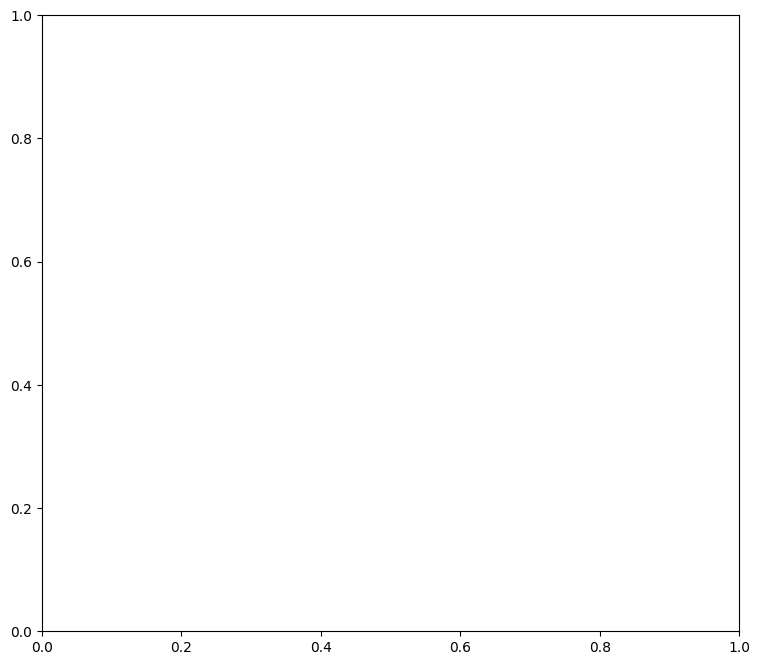

In [67]:
%matplotlib inline
x_y = np.array(x)/25.09
x_y2 = np.array(x2)/23.09
x_y3 = np.array(x3)/23.09



plt.figure(figsize=(9, 8))
plt.scatter((ene),np.log10(x_y), label = 'Sector 1(2 Min)' , c='purple', marker = '*')
plt.scatter([32.4],[34.9903], marker = 'o')
plt.scatter((ene2),np.log10(x_y2), label = 'Sector 27(2 Min)', c='green', marker = '+')
plt.scatter((ene3),np.log10(x_y3),label = 'Sector 27(20 sec)',c='black', marker = '^')

# Adicione um quadrado (retângulo) com cores diferentes para as áreas claras e escuras
square = patches.Rectangle((34, -1), 4, 4, linewidth=1, edgecolor='red', facecolor='darkorange', alpha=0.3,label='Ozone depletion')
plt.gca().add_patch(square)

# Crie um retângulo menor para a área mais clara
light_orange = patches.Rectangle((34, -1), 4, 0.6, linewidth=1, edgecolor='none', facecolor='lightcoral', alpha=0.15)
plt.gca().add_patch(light_orange)

plt.plot([34, 38], [-1, -1], color='red', linestyle='-.', linewidth=1, label='log(0.1)[$d^{-1}$]')
plt.plot([34, 38], [-0.4, -0.4], color='red', linestyle=':', linewidth=1 ,label='log(0.4)[$d^{-1}$]')
plt.plot([34, 34], [-1, 1], color='red', linestyle='--', linewidth=1)


#plt.plot((ene),x_y, label = 'Sector 1(2 Min)' )
#plt.plot((ene2),x_y2, label = 'Sector 27(2 Min)')
#plt.plot((ene3),x_y3,label = 'Sector 27(20 sec)')
plt.legend()
#plt.ylim(-1.5,0)
#plt.xlim(31.5,34.5)
plt.ylim(-3.0,1)
plt.xlim(30,38)
plt.title('AU Mic')
plt.xlabel("Energy [ergs]")
plt.ylabel("log(cum $v_{flares}$)[$d^{-1}$]");
#plt.yscale('log')
plt.show()
print(ene)
print(x_y)

In [52]:
import random as rd

vg = []

for x in np.linspace(30.5,32.3,20):
    vg.append(25.5*((10e34)/10**(x))*((R_star)**2)*((T_star/T_sun)**4))

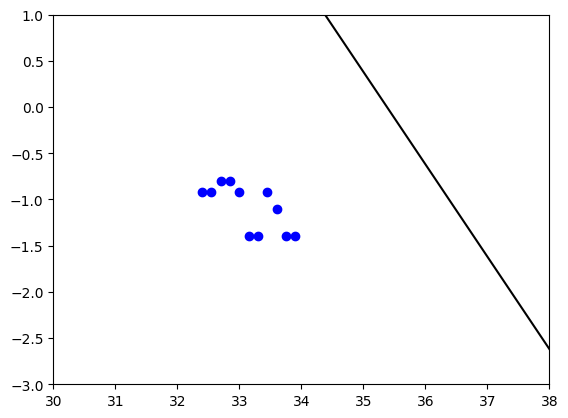

In [53]:
E_u = np.linspace(30.5,32.3,20)
coefficients1 = np.polyfit(E_u, np.log10(vg), 1)
slope1=coefficients1[0]
intercept1 = ((np.log10(vg[0]) - (slope1*E_u[0])))
xene3 = [i for i in range(30,40)]
yv4 = [(xene3[i])*slope1  + intercept1   for i in range(len(xene3))]
plt.scatter((ene),np.log10(x_y), label = 'Sector 1(2 Min)' , c='blue', marker = 'o')

plt.plot(xene3,yv4, c = 'black')

plt.ylim(-3.0,1)
plt.xlim(30,38)

plt.show()

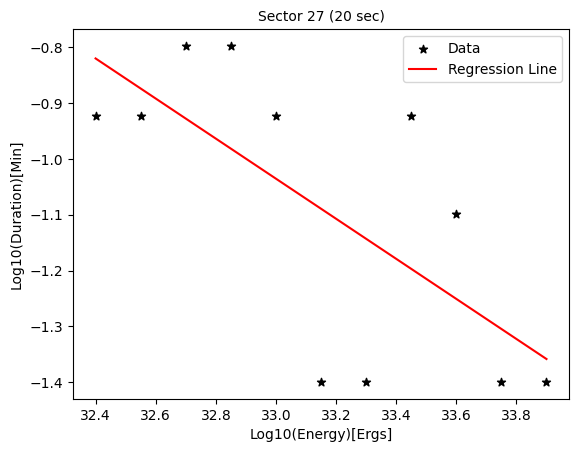

Coeficiente Angular (Slope): -0.3590412125700098
Coeficiente Linear (Intercept): 10.813045989671993
Coeficiente de Correlação (r): -0.6917284031339858
Valor-p (p-value): 0.018368902005273354
Erro Padrão (Standard Error): 0.12494518231658527



In [45]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Exemplo de dados de entrada e saída
X =np.array(ene)
y =np.array(np.log10(x_y))
# Use linregress para ajustar o modelo linear
slope, intercept, r_value, p_value, std_err = linregress(X, y)

# Faça previsões para os valores existentes de X
predictions = slope*X + intercept

# Plote os dados originais e a linha de regressão
plt.scatter(X, y, label='Data', color='black', marker="*")
plt.plot(X, predictions, label='Regression Line', color='red')
plt.ylabel('Log10(Duration)[Min]')
plt.xlabel('Log10(Energy)[Ergs]')
plt.legend()
plt.title('Sector 27 (20 sec)')
plt.show()

# Imprima os coeficientes e outras estatísticas
print(f"Coeficiente Angular (Slope): {slope}")
print(f"Coeficiente Linear (Intercept): {intercept}")
print(f"Coeficiente de Correlação (r): {r_value}")
print(f"Valor-p (p-value): {p_value}")
print(f"Erro Padrão (Standard Error): {std_err}")

print()

[4.10094466 3.95094466 3.80094466 3.65094466 3.50094466 3.35094466
 3.20094466 3.05094466 2.90094466 2.75094466 2.60094466]
35.0
[2.51188643e+32 3.54813389e+32 5.01187234e+32 7.07945784e+32
 1.00000000e+33 1.41253754e+33 1.99526231e+33 2.81838293e+33
 3.98107171e+33 5.62341325e+33 7.94328235e+33]
-0.9999999999999929


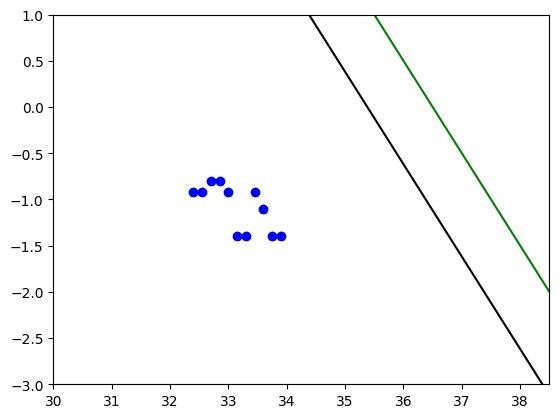

In [46]:
#Flare frequence minumun to make pre-biotic life 
T_star = 3700
R_star = 0.75
T_sun = 5780
Eu = (10**(np.array(ene)))*0.076

v = [25.5*((10e34)/Eu[i])*((R_star)**2)*((T_star/T_sun)**4) for i in range(len(ene))]
print(np.log10(v))
print(np.log10(10e34))
plt.scatter((ene),np.log10(x_y), label = 'Sector 1(2 Min)' , c='purple', marker = '*')

coefficients = np.polyfit(ene, np.log10(v), 1)  # O número 1 especifica um ajuste linear (uma reta)

# O coeficiente 1 do resultado é a inclinação (slope)
slope = coefficients[0]
intercept =   np.log10(v[1]) - slope *ene[1] 
xene = [i for i in range(30,40)]
yv = [xene[i]*slope + intercept for i in range(len(xene))]
plt.plot(xene,yv, c = 'green')
print(10**(np.array(ene)))
plt.scatter((ene),np.log10(x_y), label = 'Sector 1(2 Min)' , c='blue', marker = 'o')


plt.plot(xene3,yv4, c = 'black')

print(slope)



plt.ylim(-3.0,1)
plt.xlim(30,38.5)

plt.show()

[4.40094466 4.20094466 4.00094466 3.80094466 3.60094466 3.40094466
 3.20094466 3.00094466 2.80094466 2.60094466 2.40094466]
35.0


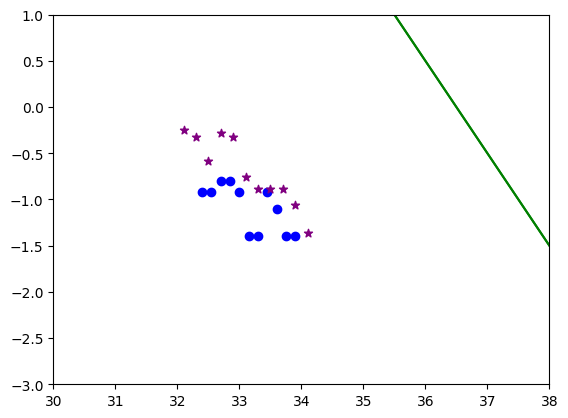

In [43]:
#Flare frequence minumun to make pre-biotic life 
T_star = 3700
R_star = 0.75
T_sun = 5780
Eu2 = (10**(np.array(ene2)))*0.076

v2 =[ 25.5*((10e34)/Eu2[i])*((R_star)**2)*((T_star/T_sun)**4) for i in range(len(ene))]
print(np.log10(v2))
print(np.log10(10e34))
plt.scatter((ene),np.log10(x_y), label = 'Sector 1(2 Min)' , c='blue', marker = 'o')

plt.scatter((ene2),np.log10(x_y2), label = 'Sector 1(2 Min)' , c='purple', marker = '*')

coefficients = np.polyfit(ene2, np.log10(v2), 1)  # O número 1 especifica um ajuste linear (uma reta)

# O coeficiente 1 do resultado é a inclinação (slope)
slope = coefficients[0]
intercept =   np.log10(v2[1]) - slope *ene2[1] 
xene2 = [i for i in range(30,40)]
yv2 = [xene2[i]*slope + intercept for i in range(len(xene2))]
plt.plot(xene2,yv2, c = 'green')
plt.plot(xene,yv, c = 'green')




plt.ylim(-3.0,1)
plt.xlim(30,38)

plt.show()

In [44]:
import random as rd


[5.00094466 4.75094466 4.50094466 4.25094466 4.00094466 3.75094466
 3.50094466 3.25094466 3.00094466 2.75094466 2.50094466]
35.0


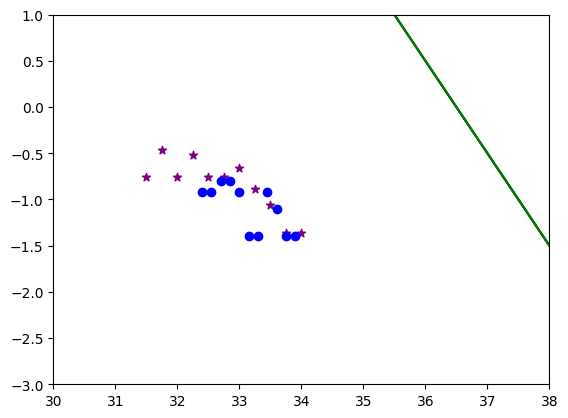

In [171]:
#Flare frequence minumun to make pre-biotic life 
T_star = 3700
R_star = 0.75
T_sun = 5780
Eu3 = (10**(np.array(ene3)))*0.076

v3 =[ 25.5*((10e34)/Eu3[i])*((R_star)**2)*((T_star/T_sun)**4) for i in range(len(ene))]
print(np.log10(v3))
print(np.log10(10e34))
plt.scatter((ene3),np.log10(x_y3), label = 'Sector 1(2 Min)' , c='purple', marker = '*')

coefficients = np.polyfit(ene2, np.log10(v2), 1)  # O número 1 especifica um ajuste linear (uma reta)

# O coeficiente 1 do resultado é a inclinação (slope)
slope = coefficients[0]
intercept =   np.log10(v3[1]) - slope *ene3[1] 
xene3 = [i for i in range(30,40)]
yv3 = [xene3[i]*slope + intercept for i in range(len(xene3))]
plt.scatter((ene),np.log10(x_y), label = 'Sector 1(2 Min)' , c='blue', marker = 'o')

plt.plot(xene2,yv2, c = 'green')
plt.plot(xene,yv, c = 'black')
plt.plot(xene3,yv3, c = 'green')
#plt.plot(xene,yv, c = 'green')




plt.ylim(-3.0,1)
plt.xlim(30,38)

plt.show()